# NODE / UDE - Remaining Useful Life (NASA C-MAPSS)

Este notebook implementa:

- Preprocesamiento de datos
- Construcción de RUL y probabilidad de falla
- NODE (Neural ODE)
- UDE (Universal Differential Equation)

In [1]:
using Pkg
Pkg.activate(".")



#solo la primera vez:
#Pkg.instantiate()

  Activating project at `c:\Users\Sebastian\Desktop\TP-DegradacionDeMotores\mi_entorno`


## Todas los paquetes que utilizaremos.

In [2]:
ENV["GKSwstype"] = "100"

using CSV
using DataFrames
using Statistics
using Plots

using Lux
using ComponentArrays
using Random
Random.seed!(42)

using OrdinaryDiffEq
using SciMLSensitivity

using Optimization
using OptimizationOptimisers
using Zygote
using DataInterpolations


## Carga de datos

In [3]:
dataset_path = joinpath(pwd(), "..", "CMaps", "train_FD001.txt")

train_df = CSV.read(
    dataset_path,
    DataFrame;
    delim=' ',
    ignorerepeated=true,
    header=false
)


#agregamos los nombres de la columnas ya que el dataset original venian sin ellos
rename!(
    train_df,
    vcat(
        ["unit", "cycle", "setting1", "setting2", "setting3"],
        ["s$i" for i in 1:21]
    )
)

first(train_df, 5)

Row,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64
1,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419
2,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236
3,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
4,1,4,0.0007,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
5,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044


## Normalización de sensores y settings

In [4]:
#Normalizamos los datos de los sensores y settings para mejorar entrenamiento de redes neuronales.


sensor_cols = ["s$i" for i in 1:21]
setting_cols = ["setting1", "setting2", "setting3"]
    
for col in sensor_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end
    
for col in setting_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end

## Construcción de RUL y probabilidad de falla.

In [5]:
#Construimos el cilo de falla. En el train la falla se da en el último ciclo observado.
fail_cycles = combine(
    groupby(train_df, :unit),
    :cycle => maximum => :T_fail
)

#Obtenemos un df de la siguiente forma:
#unit    T_fail
#1       192

#Ahora mergeamos con el dataset original
train_df = leftjoin(train_df, fail_cycles, on=:unit)

#Ahora empezamos a construir la proba de falla en cada ciclo.
train_df.RUL = train_df.T_fail .- train_df.cycle

#Para construir la proba vamos a utilizar un funcion sigmoide, que sea baja           lejos de la falla y aumenta rapido cerca de la falla.
      
σ(x) = 1 / (1 + exp(-x))


#Estos hiperparametros habria que chequearlos bien...
k = 0.08
threshold = 40
    
train_df.p_fail = σ.(k .* (threshold .- train_df.RUL))

20631-element Vector{Float64}:
 5.671790689635885e-6
 6.144174602214718e-6
 6.6559014820897696e-6
 7.2102480022617275e-6
 7.810763725056275e-6
 8.461293827645233e-6
 9.16600371985333e-6
 9.929405711774312e-6
 1.0756387901826074e-5
 1.165224547006964e-5
 1.2622714576991388e-5
 1.3674009084599712e-5
 1.4812860334722366e-5
 ⋮
 0.9105199406664386
 0.9168273035060777
 0.9227277978633401
 0.9282424577362486
 0.9333919644249093
 0.9381965337364114
 0.9426758241011313
 0.9468488636019362
 0.9507339939159732
 0.9543488292155562
 0.9577102281579662
 0.9608342772032357

## Ejemplo de curva de falla

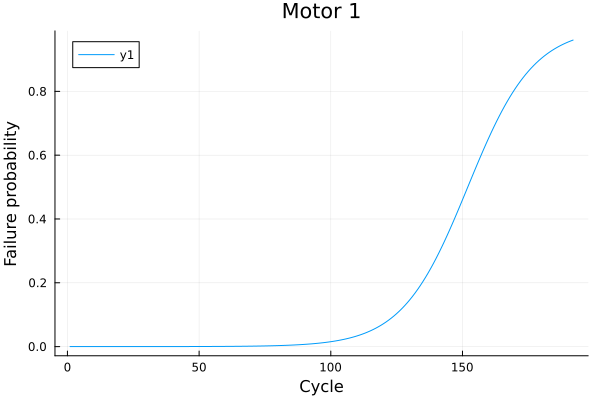

In [6]:
motor1 = filter(row -> row.unit == 1, train_df)
    
plt = plot(
    motor1.cycle,
    motor1.p_fail,
    xlabel="Cycle",
    ylabel="Failure probability",
    title="Motor 1"
)
    
plt

##  Trayectorias por motor

In [7]:
#agrupamos por unidad
grouped = groupby(train_df, :unit)
    
trajectories = []
    
for g in grouped
    X = Matrix(g[:, vcat(setting_cols, sensor_cols)])
    y = g.p_fail
    t = g.cycle
    
    push!(trajectories, (X=X, y=y, t=t))
end

##  NODE: dp/dt = NN(p, t)

NODE simple donde solo usamos los ciclos. Todavia no incorporamos sensores.

In [8]:
#elegimos una trayectoria
traj = trajectories[1]

print(trajectories)

t = Float64.(traj.t)
y = Float64.(traj.y)
    
u0 = [y[1]]
    
#generador de numeros aleatorios, sirve para inicializar los pesos de la red
rng = Random.default_rng()

#estructura de la red
nn = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#p: parametros entrenables de la red, st: estados internos
p_node, st_node = Lux.setup(rng, nn)
#esto es para que funcione bien la optimizacion
p_node = ComponentArray(p_node)

Any[(X = [-0.31597202195452145 -1.3729199290729734 NaN 0.9999757643323645 -1.7216836648226865 -0.13425192213570927 -0.925913523696359 -0.9999757643323643 0.14167989491882235 1.1211133982073023 -0.516325892386186 -0.8627924043441415 0.9999757643323643 -0.2664601377187745 0.33425373913469153 -1.0588645739680291 -0.26906451920303553 -0.603801065881639 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.3484600620382499 1.1943981001535333; 0.8727007771683792 -1.0316953503320596 NaN 0.9999757643323645 -1.0617539738121262 0.2115233673416215 -0.6437102649230355 -0.9999757643323643 0.14167989491882235 0.4319197071333588 -0.7980736570341316 -0.9587943771663178 0.9999757643323643 -0.1915782821843463 1.174870847738156 -0.3636371846989997 -0.6428291567796645 -0.27584512524895916 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.0165032941737064 1.2368919830975704; -1.9618266668939224 1.015652122113423 NaN 0.9999757643323645 -0.6617965853206986 -0.4131555754405577 -0.5259404010255218 -0.9999757643323

Excessive output truncated after 524288 bytes.

 1.356876700854337 NaN 0.9999757643323645 0.5180777107288085 -0.5191715840067408 -0.6414881920193107 -0.9999757643323643 0.14167989491882235 0.0025859323659988644 0.32891740155765065 -1.0303430172884753 0.9999757643323643 -0.15413735441714546 0.10376195129186329 0.748726638126389 -1.186963369689256 1.6199001901153058 -0.9999757643323645 0.5096623027963773 NaN NaN 1.3484600620382499 -0.6781040895761323; -0.08738109904627135 -0.008021614109318172 NaN 0.9999757643323645 -1.2417347986332914 -0.48818228919508266 -0.36706218840904914 -0.9999757643323643 0.14167989491882235 -1.0142572183987875 0.8924129308535417 -1.066570176843967 0.9999757643323643 -0.004373643348315592 -0.30298826254845806 0.3315902045637067 -1.2519659153547444 -0.7851100411907438 -0.9999757643323645 -0.13601426883344866 

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.18582273 0.073365726; -1.3326262 1.9626849; … ; -1.2206342 0.22496898; 1.2360227 0.50070494], bias = Float32[0.45274794, -0.109943174, 0.2535509, 0.33633876, -0.58940434, -0.5645052, -0.6811371, -0.25305128, 0.11489113, 0.6639945, -0.4025346, -0.6888659, -0.4826754, 0.3613354, 0.48929778, -0.21674016]), layer_2 = (weight = Float32[0.3199716 0.046035804 … 0.03958083 -0.19888853], bias = Float32[-0.0893096]))

Definimos la NODE

In [9]:
function node!(du, u, p, t)
    input = [u[1], t]

    du .= nn(input, p, st_node)[1]
end

node! (generic function with 1 method)

In [10]:
#todo el intervalo de tiempo
tspan = (t[1], t[end])
	
#definimos el problema de ode
prob_node = ODEProblem(node!, u0, tspan, p_node)
	
#resolvemos con solver numerico
sol = solve(prob_node, Tsit5(), saveat=t)

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [Matrix{Float64}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl C:\Users\Sebastian\.julia\packages\LuxLib\zPBrt\src\impl\matmul.jl:194


retcode: Success
Interpolation: 1st order linear
t: 192-element Vector{Float64}:
   1.0
   2.0
   3.0
   4.0
   5.0
   6.0
   7.0
   8.0
   9.0
  10.0
  11.0
  12.0
  13.0
   ⋮
 181.0
 182.0
 183.0
 184.0
 185.0
 186.0
 187.0
 188.0
 189.0
 190.0
 191.0
 192.0
u: 192-element Vector{Vector{Float64}}:
 [5.671790689635885e-6]
 [-0.6389859493328393]
 [-1.1971182814602073]
 [-1.690072756169595]
 [-2.1514591085398314]
 [-2.5924914293618455]
 [-3.0142288955066787]
 [-3.41512428090587]
 [-3.7941918771853764]
 [-4.152477724694881]
 [-4.4935622499326975]
 [-4.822654969579479]
 [-5.145814746895945]
 ⋮
 [-72.39173281608667]
 [-72.79671447659534]
 [-73.20170800458831]
 [-73.60671244711838]
 [-74.01172685927285]
 [-74.41675030417355]
 [-74.82178185297677]
 [-75.22682058487337]
 [-75.63186558708865]
 [-76.03691595488252]
 [-76.44197079154928]
 [-76.84702920841788]

## Predicción sin entrenamiento

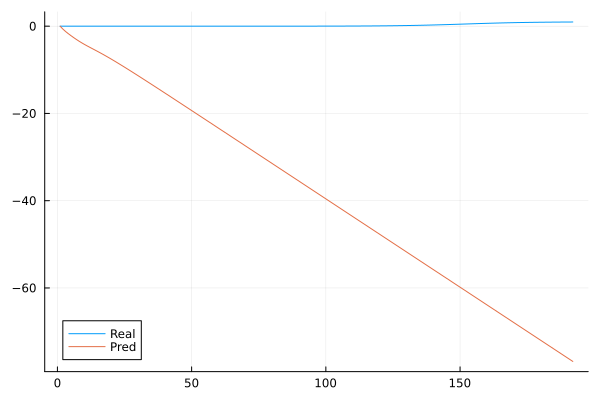

In [11]:
plt2 = plot(t, y, label="Real")
plot!(plt2, t, vec(Array(sol)), label="Pred")
	
plt2

Como se puede observar, al no haber entrenado la red no obtenemos buenos resultados.

##  Entrenamiento NODE

In [12]:
#funcion de prediccion
function predict(prob, p, t)

    _prob = remake(prob, p=p)
    
    sol = solve(
        _prob,
        Tsit5(),
        saveat=t
    )
    
    Array(sol)[1, :]
end

#funcion de perdida basica
function loss(prob, p, t, y)

    pred = predict(prob, p, t)
    
    sum(abs2, pred .- y)

end

loss (generic function with 1 method)

In [13]:
#convertimos la funcion loss en algo digerible por el optimizador. Con AutoZygote() calculamos los gradientes.
optf_node = OptimizationFunction((x, _) -> loss(prob_node,x,t,y), AutoZygote())

#Define el problema de opt. Quiero minimizar optf empezando de parametros iniciales p.
optprob_node = OptimizationProblem(optf_node, p_node)

#Resulve el problema de opt. Con Adam version de descenso por el gradiente y 0.01 el learning rate.
result_node = Optimization.solve(optprob_node, Adam(0.01), maxiters=500)
	
p_trained_node = result_node.u

#prediccion final luego de entrenar:
pred_node = predict(prob_node, p_trained_node, t)

192-element Vector{Float64}:
  5.671790689635885e-6
 -0.04486189459213208
 -0.09923701153516558
 -0.10557307590261993
 -0.08825253220874044
 -0.06583979844147159
 -0.0454655777956574
 -0.028559856620187892
 -0.01470540925328058
 -0.003102457060216534
  0.006904103000575
  0.01578480792529694
  0.023850731578054535
  ⋮
  0.5060307930153963
  0.5087826946345434
  0.511393606125688
  0.5138622514178848
  0.5163580730718544
  0.5190931110050987
  0.5218390301951028
  0.5244324199162117
  0.5268896469724834
  0.5294020026491865
  0.5320855595302143
  0.5347326611146708

Graficamos la sol obtenida

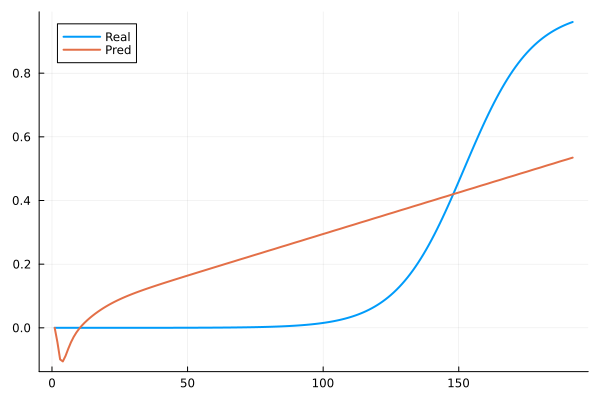

In [14]:
p1 = plot(
        t,
        y,
        label="Real",
        linewidth=2
    )
    
plot!(
    p1,
    t,
    pred_node,
    label="Pred",
    linewidth=2
)

p1

##  UDE: término físico + red neuronal

dp/dt = -αu + NN(p,t) 

In [18]:
#Definimos la red
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#parametros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)
    
α = 0.05

#definimos ude
function ude!(du, u, p, t)

    input = [u[1], t]
    du .= .-α .* u .+ nn2(input, p, st_ude)[1]

end

#definimos problema ode
prob_ude = ODEProblem(ude!, u0, tspan, p_ude)

#mismo proceso de antes
optf_ude = OptimizationFunction(
(x, _) -> loss(prob_ude,x,t,y),
AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u
pred_ude = predict(prob_ude, p_trained_ude, t)

192-element Vector{Float64}:
  5.671790689635885e-6
 -0.061447313534606245
 -0.07086889022197612
 -0.06397477977198249
 -0.04961585669353098
 -0.031730414647267585
 -0.012928846057972409
  0.005254253107875892
  0.02208068140925927
  0.03734137222054434
  0.05107939522757967
  0.06345708791847382
  0.07466460400472885
  ⋮
  0.2584955368809033
  0.2584974804948669
  0.25849939675518224
  0.2585012339575109
  0.25850298157402646
  0.2585046439206526
  0.2585062251360646
  0.25850772918168935
  0.2585091598417055
  0.25851052072304337
  0.2585118152553849
  0.25851304669116365

Graficamos la sol obtenida:

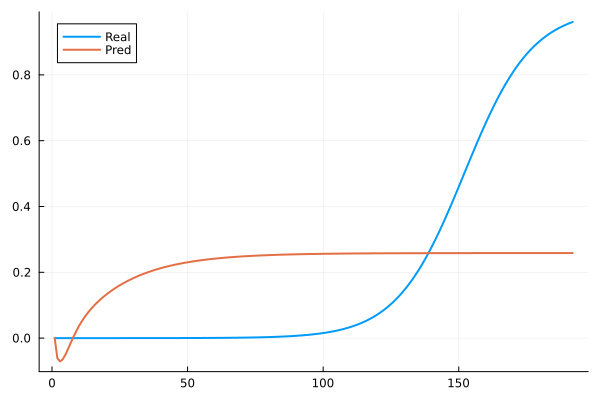

In [19]:
p2 = plot(
    t,
    y,
    label="Real",
    linewidth=2
    )
    
plot!(
    p2,
    t,
    pred_ude,
    label="Pred",
    linewidth=2
)

##  UDE: término físico + red neuronal agregando motores


In [20]:
#Ahora tengamos en cuenta mas de una trayectoria de motor.

#hago una funcion para no practicar con todas las trajs a la ves, si no tarda demasiado

n_motors = length(trajectories)


function build_train_trajs(trajectories; n_motors=nothing, shuffle=false, seed=1234)

    total_motors = length(trajectories)

    if n_motors === nothing
        selected_ids = collect(1:total_motors)
    else
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = collect(1:n)
    end


    #esto recontraponele, capaz sirve capaz no, pero como el test te da cualquier motor esto lo hace mas random
    if shuffle
        rng = Random.default_rng()
        Random.seed!(rng, seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    train_trajs = [
        (
            X = trajectories[i].X,
            t = Float64.(trajectories[i].t),
            y = Float64.(trajectories[i].y)
        )
        for i in selected_ids
    ]

    return train_trajs
end

function predict_traj(f!, p, traj)

    t = traj.t
    y = traj.y

    u0 = [y[1]]
    tspan = (t[1], t[end])

    prob = ODEProblem(f!, u0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=t,
        abstol=1e-6,
        reltol=1e-6
    )

    return Array(sol)[1, :]
end

function loss_many(f!, p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj(f!, p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points
end

loss_many (generic function with 1 method)

La función de pérdida total sobre varios motores se define como:

$$
\mathcal{L}(\theta)
=
\frac{1}{\sum_{i=1}^{M} T_i}
\sum_{i=1}^{M}
\sum_{j=1}^{T_i}
\left(
\hat{y}_{i,j}(\theta) - y_{i,j}
\right)^2
$$

In [21]:
#para las pruebas vamos con 10.



# Definimos la red de la UDE
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

# Parámetros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)

# Parámetro fijo de la parte mecanística
α = 0.05




0.05

In [22]:
train_trajs = build_train_trajs(trajectories, n_motors=10)

optf_ude = OptimizationFunction(
    (x, _) -> loss_many(ude!, x, train_trajs),
    AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u

usando 10 de 100 motores


ComponentVector{Float32}(layer_1 = (weight = Float32[-0.586815 0.44284847; -0.7939531 -0.44054532; … ; 1.2437595 -0.20910375; 0.4200476 -0.27430984], bias = Float32[-0.17682967, 0.21515447, -0.5131707, -0.09115177, -0.4344378, -0.7183299, -0.5081968, -0.29840264, -0.6234897, -0.40290675, -0.34372148, -0.13114385, -0.04090764, 1.3274114, 0.24768177, 0.49914154]), layer_2 = (weight = Float32[-0.46066478 -0.2002062 … -0.019119479 0.29739448], bias = Float32[0.11526927]))

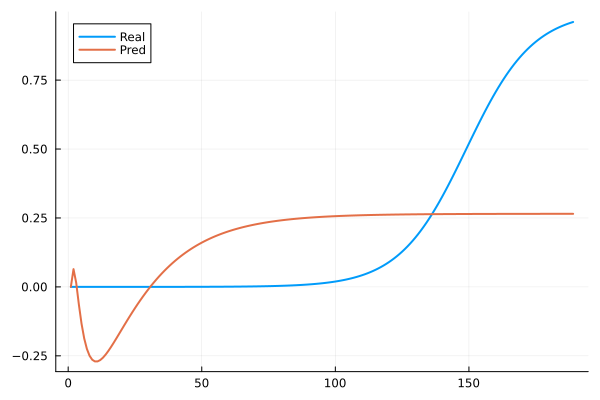

In [23]:
traj_plot = train_trajs[4]

pred_ude_n = predict_traj(ude!, p_trained_ude, traj_plot)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_n,
    label="Pred",
    linewidth=2
)

Empeora bastante... Esto puede ser ya que estoy intentando generalizar para todos los motores, sin tener cuenta los sensores. entonces, cuando veo para el caso particular 1, no calcula bien.

Si aumento cnt de motores a 30:


usando 30 de 100 motores


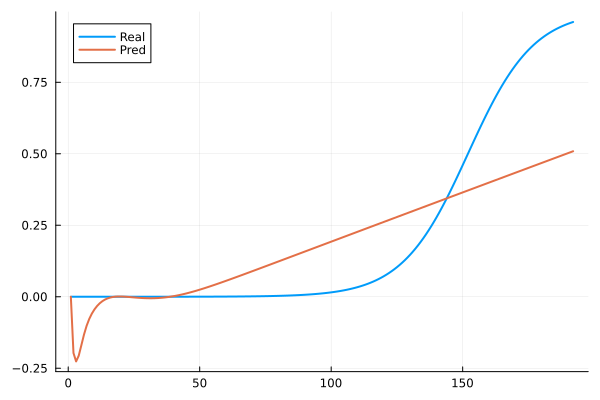

In [24]:


# Definimos la red de la UDE
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

# Parámetros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)

# Parámetro fijo de la parte mecanística
α = 0.05


train_trajs = build_train_trajs(trajectories, n_motors=30)

optf_ude = OptimizationFunction(
    (x, _) -> loss_many(ude!, x, train_trajs),
    AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u

traj_plot = train_trajs[1]

pred_ude_n = predict_traj(ude!, p_trained_ude, traj_plot)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_n,
    label="Pred",
    linewidth=2
)

##  UDE: término físico + red neuronal + sensores para 1 (un) motor (no sabes lo q tarda en correr con 10)

dp/dt = -αu + NN(p,t,sens) 

A partir de acá vamos a realizar diferentes entrenamientos donde utilizamos una red neuronal y sus pesos. Para evitar utilizar pesos ya entrenados y hacerlo más limpio definimos la siguiente función:

In [25]:
function init_model(input_dim)

    nn = Lux.Chain(
        Lux.Dense(input_dim, 8, tanh),
        Lux.Dense(8, 1)
    )

    rng = MersenneTwister(1234)

    p, st = Lux.setup(rng, nn)

    return nn, ComponentArray(p), st
end

init_model (generic function with 1 method)

In [26]:
function build_train_trajs_sensors(trajectories; n_motors=nothing, shuffle=false,sensors=nothing, seed=67)

    total_motors = length(trajectories)

    selected_ids = collect(1:total_motors)

    if shuffle
        rng = MersenneTwister(seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    if n_motors !== nothing
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = selected_ids[1:n]
    end

    # default: usar todos los sensores
    if sensors === nothing
        sensors = 4:size(trajectories[1].X, 2)
    end

    train_trajs = []

    for i in selected_ids

        t = Float64.(trajectories[i].t)

        S = Float64.(trajectories[i].X[:, sensors])

        # un interpolador por sensor, para que no quede todo discreto y de a saltos.
        sensor_interps = [
            LinearInterpolation(S[:, j], t)
            for j in 1:size(S,2)
        ]
        #esto termina siendo como funciones para cada sensor: s_1(t), s_2(t), ....

        push!(train_trajs,
            (
                sensor_interps = sensor_interps,
                sensors_ids = sensors,                  #para no perder los sensores que utilizamos
                t = t,
                y = Float64.(trajectories[i].y)
            )
        )
    end

    return train_trajs
end

build_train_trajs_sensors (generic function with 1 method)

In [27]:
train_trajs_sensors = build_train_trajs_sensors(
    trajectories;
    n_motors=1,
    sensors = [6,7]
)
n_sensors = length(train_trajs_sensors[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

α = 0.05


function ude_sensors!(du, u, p, τ, S)

    input = [u[1]; τ; S] #esto antes estaba en Float32, pero eso rompía las cosas

    out, _ = nn2(input, p, st_ude_sensors)

    du[1] = -α * u[1] + out[1]

end


function predict_traj_sensors(p, traj)

    tvec = traj.t
    y = traj.y
    

    u0 = [y[1]]

    t0 = tvec[1]
    tf = tvec[end]
    tspan = (t0, tf)

    function f!(du, u, p, t)

        S = [
            interp(clamp(t, t0, tf))
            for interp in traj.sensor_interps
        ]

        τ = (t - t0) / (tf - t0)

        ude_sensors!(du, u, p, τ, S)

    end

    prob = ODEProblem(f!, u0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax = 1.0
    )

    return Array(sol)[1, :]

end

usando 1 de 100 motores
Cantidad de sensores usados: 2


predict_traj_sensors (generic function with 1 method)

In [28]:
function loss_many_sensors(p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj_sensors(p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points

end

loss_many_sensors (generic function with 1 method)

In [29]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)

result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3), #baje el learning rate, para que no se vuelva loco el optimizador
    maxiters=500, 
    callback = (state, loss) -> begin
        println(loss)
        false
    end
)

p_trained_ude_sensors = result_ude_sensors.u

0.6141156670792293
0.5990159716011335
0.5841686031130789
0.5695945158353263
0.5552175915469346
0.541134869886645
0.5272719742529888
0.5136757645137989
0.5002830008726932
0.4870505535591625
0.4740877171546503
0.4612827133909742
0.44871801895325353
0.43632347003222144
0.4241459941577686
0.4122092973087426
0.40044756933629816
0.38891449587495824
0.37759469121769146
0.3665047819202723
0.3556429238774288
0.34497517553039286
0.3345546992491845
0.3243666782797519
0.31437887368359624
0.3046506175726942
0.2951582111611946
0.2858990491775749
0.2768761744967817
0.2680731038543111
0.25954253881829226
0.2512202062285845
0.24317333712307324
0.23535179464196052
0.22776569129979393
0.22041586991204665
0.2133106927160677
0.20643838241011123
0.1998089376867305
0.1934040026361793
0.18723911589558898
0.1812952837677612
0.17557646966059437
0.17008882771656156
0.16480332012551221
0.1597322427703522
0.1548710626775354
0.1501995814786776
0.1457300273729468
0.14144400988817993
0.1373462555539902
0.133421972799

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.8577532 0.0005762968 0.93696815 -1.1014127; -1.285365 0.6137114 1.3247628 -0.6086901; … ; 0.7792491 -1.5391353 -0.30181146 -1.0852968; 0.8859146 -0.71981406 -0.44411898 -0.8760538], bias = Float32[0.16069017, 0.3850403, -0.4697758, -0.014890724, -0.111921154, 0.26521763, 0.0005236699, 0.21318713]), layer_2 = (weight = Float32[-0.14218329 -0.2102178 … 0.26286045 -0.18262437], bias = Float32[0.15843083]))

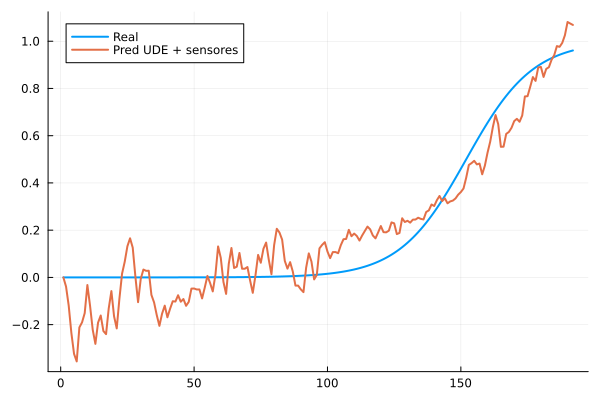

In [30]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

## Resumen hasta acá...

Realizamos los siguientes experimentos:

+ Modelamos el problema como una NODE, solo utilizando el estado actual y el tiempo
+ Modelamos con una UDE, pero seguimos sin usar sensores
+ Entrenamos la UDE con más de una trayectoria
+ Incorporamos los sensores al modelo

Pero en el último paso nos encontramos con un problema....

Si agregamos todos los sensores al modelo nos termina quedando algo muy complejo que tarda muchísimo en correr. Entonces planteamos el siguente paso:

**Vamos a estudiar los sensores y decidir cuales son los más influyentes en el estudio de la dinámica de probabilidad de falla**

## Selección de sensores

### 1. Estudiamos varianza de los sensores

In [31]:
variances = DataFrame(
    sensor = sensor_cols,
    variance = [
        var(train_df[!, col])
        for col in sensor_cols
    ]
)

sort!(variances, :variance, rev=true)

variances

Row,sensor,variance
,String,Float64
1,s18,NaN
2,s19,NaN
3,s6,1.0
4,s2,1.0
5,s17,1.0
6,s4,1.0
7,s8,1.0
8,s9,1.0
9,s11,1.0


Recordemos que al principio del trabajo normalizamos los datos de los sensores utilizando la transformación:

$$
\frac{x - \mu}{\sigma}
$$

Por lo tanto, observamos que:

- Dos sensores presentan $Var = NaN$. Esto ocurre debido a que $\sigma = 0$, es decir, el sensor toma un valor constante para todo instante de tiempo y, por lo tanto, no aporta información útil al modelo.

- Cuatro sensores presentan una varianza muy pequeña. En consecuencia, son sensores casi constantes y decidimos excluirlos del análisis.

- Los sensores restantes presentan $Var = 1$, lo cual es esperable luego del proceso de normalización. Estos sensores son los que superan el primer filtro de selección.

In [32]:
#Definimos los sensores válidos hasta el momento:

valid_sensors = []

for col in sensor_cols

    σ_col = std(train_df[!, col])

    if !isnan(σ_col) && σ_col > 1e-8
        push!(valid_sensors, col)
    end
end

println(valid_sensors)

Any["s2", "s3", "s4", "s6", "s7", "s8", "s9", "s11", "s12", "s13", "s14", "s15", "s17", "s20", "s21"]


### 2. Correlación con RUL

La idea es identificar sensores cuyo comportamiento esté fuertemente asociado al proceso de degradación del motor.

Utilizamos el coeficiente de correlación de Pearson:

$$
\rho_{X,Y} = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}
$$

Valores cercanos a:

- $1$ indican correlación positiva fuerte
- $-1$ indican correlación negativa fuerte
- $0$ indican ausencia de correlación lineal

In [33]:
correlations = DataFrame(
    sensor = valid_sensors,
    correlation = [
        cor(train_df[!, col], train_df.RUL)
        for col in valid_sensors
    ]
)

correlations.abs_corr = abs.(correlations.correlation)

sort!(correlations, :abs_corr, rev=true)

correlations

Row,sensor,correlation,abs_corr
,Any,Float64,Float64
1,s11,-0.696228,0.696228
2,s4,-0.678948,0.678948
3,s12,0.671983,0.671983
4,s7,0.657223,0.657223
5,s15,-0.642667,0.642667
6,s21,0.635662,0.635662
7,s20,0.629428,0.629428
8,s2,-0.606484,0.606484
9,s17,-0.606154,0.606154


### 3. Correlación entre sensores

Hasta ahora miramos la correlación entre los sensores y RUL. Si nos quedamos con los que maximicen esta cantidad puede pasar que seleccionemos sensores que estén muy correlacionados entre ellos. Entonces estudiaremos tambíen la correlación entre sensores:

In [34]:
sensor_corr = cor(Matrix(train_df[:, valid_sensors]))

sensor_corr_df = DataFrame(
    sensor_corr,
    Symbol.(valid_sensors)
)

sensor_corr_df

Row,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1.0,0.60261,0.714949,0.132242,-0.702136,0.662325,0.273764,0.74002,-0.724578,0.661792,0.179752,0.675975,0.629886,-0.661841,-0.66805
2,0.60261,1.0,0.678413,0.116039,-0.664595,0.602481,0.322964,0.6959,-0.680307,0.600963,0.237137,0.639921,0.600017,-0.625941,-0.633901
3,0.714949,0.678413,1.0,0.15048,-0.79313,0.746852,0.297429,0.830136,-0.815591,0.745158,0.190748,0.758459,0.703499,-0.748067,-0.745193
4,0.132242,0.116039,0.15048,1.0,-0.15572,0.152161,0.0193472,0.160014,-0.155884,0.158276,-0.00211233,0.149042,0.13081,-0.141419,-0.137419
5,-0.702136,-0.664595,-0.79313,-0.15572,1.0,-0.767132,-0.217835,-0.822805,0.812713,-0.764611,-0.110053,-0.747051,-0.692893,0.736163,0.737447
6,0.662325,0.602481,0.746852,0.152161,-0.767132,1.0,-0.0320911,0.782213,-0.78654,0.826084,-0.144787,0.700949,0.627785,-0.68703,-0.68884
7,0.273764,0.322964,0.297429,0.0193472,-0.217835,-0.0320911,1.0,0.274591,-0.210238,-0.0347625,0.963157,0.293753,0.33711,-0.28528,-0.292795
8,0.74002,0.6959,0.830136,0.160014,-0.822805,0.782213,0.274591,1.0,-0.846884,0.780761,0.163408,0.780913,0.722296,-0.77151,-0.772554
9,-0.724578,-0.680307,-0.815591,-0.155884,0.812713,-0.78654,-0.210238,-0.846884,1.0,-0.788441,-0.0981405,-0.766052,-0.703485,0.751943,0.756263


Ahora realizaremos una selección greedy sin redundancia:
+ Ordenamos por correlación con RUL
+ Descartamos sensores muy correlacionados entre sí (si la correlación es mayor a 0.8 no lo utilizamos)

In [35]:
threshold = 0.8

selected_sensors = String[]

for sensor in correlations.sensor

    keep = true

    for selected in selected_sensors

        c = cor(
            train_df[:, sensor],
            train_df[:, selected]
        )

        if abs(c) > threshold
            keep = false
            break
        end
    end

    if keep
        push!(selected_sensors, sensor)
    end

    # nos quedamos con 5
    if length(selected_sensors) >= 5
        break
    end
end

In [36]:
feature_cols = vcat(setting_cols, sensor_cols)

sensor_indices = [
    findfirst(==(s), feature_cols)
    for s in selected_sensors
]

5-element Vector{Int64}:
 14
 18
 24
 23
  5

In [37]:
for (s, idx) in zip(selected_sensors, sensor_indices)
    display( s)
    display( idx)
    
end
#no puedo ver el output

"s11"

14

"s15"

18

"s21"

24

"s20"

23

"s2"

5

Ahora veamos como evolucionan algunos de los sensores elegidos comparados con la probabilidad de falla:

In [38]:
function plot_sensor_vs_pfail(sensor_name; unit_id=1)

    motor = filter(row -> row.unit == unit_id, train_df)

    p = plot(
        motor.cycle,
        motor[!, sensor_name],
        xlabel="Cycle",
        ylabel=sensor_name,
        label=sensor_name,
        linewidth=2
    )

    plot!(
        p,
        motor.cycle,
        motor.p_fail,
        ylabel="p_fail",
        label="p_fail",
        linewidth=2,
        yaxis=:right
    )

    return p
end


plot_sensor_vs_pfail (generic function with 1 method)

┌ Warning: Skipped yaxis arg right
└ @ Plots C:\Users\Sebastian\.julia\packages\Plots\GIume\src\axes.jl:75


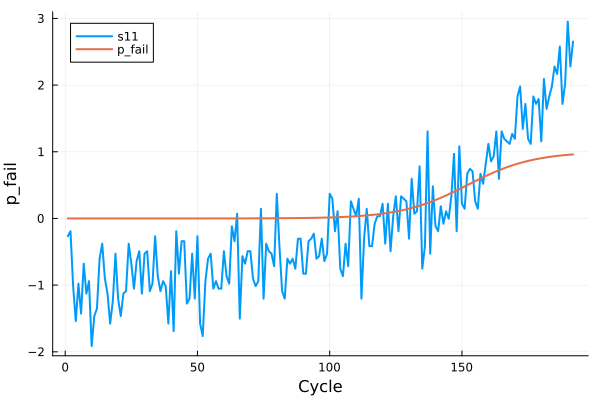

┌ Warning: Skipped yaxis arg right
└ @ Plots C:\Users\Sebastian\.julia\packages\Plots\GIume\src\axes.jl:75


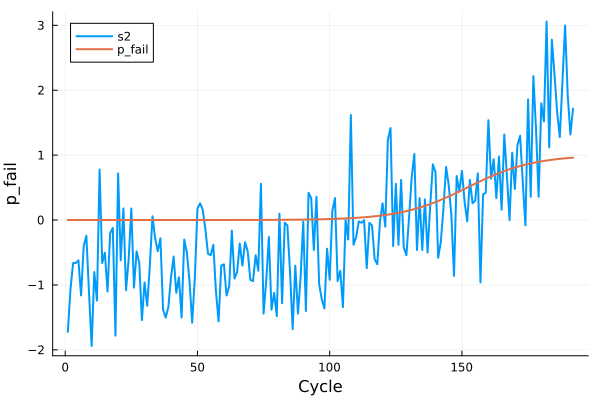

In [39]:
display(plot_sensor_vs_pfail("s11"))
display(plot_sensor_vs_pfail("s2"))

Luego de esto damos por finalizada la selección de sensores!

## UDE de antes usando los mejores sensores

En las primeras versiones del modelo utilizamos una dinámica sencilla de la forma:

$$
\frac{dp}{dt} = -\alpha p + NN(p,\tau,S(t))
$$

donde:

- $p(t)$ representa la probabilidad de falla,
- $\alpha p$ corresponde a un término físico simple,
- y $NN(\cdot)$ modela efectos no lineales aprendidos a partir de los datos.

Vamos a poner a prueba este modelo nuevamente. Pero esta vez utilizaremos los mejores sensores.

In [40]:
train_trajs_sensors = build_train_trajs_sensors(
    trajectories;
    n_motors=1,
    sensors = sensor_indices
)
n_sensors = length(train_trajs_sensors[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)


usando 1 de 100 motores
Cantidad de sensores usados: 5


(Chain{@NamedTuple{layer_1::Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}((layer_1 = Dense(7 => 8, tanh), layer_2 = Dense(8 => 1)), nothing), (layer_1 = (weight = Float32[-0.7408691 -0.10326696 … -0.31419405 0.60451025; -1.0432168 0.3961915 … -0.37899157 0.34615695; … ; 0.71916956 -0.96607554 … 0.13166444 -0.49240565; 0.6046512 -0.64713013 … -0.20698707 0.8680423], bias = Float32[0.22285166, -0.17147908, 0.34149525, 0.09755093, -0.2741171, -0.075842164, -0.33706185, 0.16103292]), layer_2 = (weight = Float32[0.32925278 0.0061875214 … 0.4209173 -0.17584868], bias = Float32[0.12733962])), (layer_1 = NamedTuple(), layer_2 = NamedTuple()))

In [41]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)


#agregamos early stopping...
best_loss = Inf
best_params = nothing

patience = 30
counter = 0
iter = 0
maxiters = 1000

callback = function (state, loss)

    global iter += 1

    if iter % 10 == 0
        println("Iteración: $iter / $maxiters | loss = $loss")

    end

    if loss < best_loss - 1e-6

        global best_loss = loss
        global best_params = deepcopy(state.u)

        global counter = 0

    else

        global counter += 1

    end

    if counter >= patience

        println("Early stopping activado")

        return true
    end

    return false
end


result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=1000,
    callback=callback
)

p_trained_ude_sensors = best_params

Iteración: 10 / 1000 | loss = 0.4726707415254616
Iteración: 20 / 1000 | loss = 0.2646317035164543
Iteración: 30 / 1000 | loss = 0.19115178579399175
Iteración: 40 / 1000 | loss = 0.16189228403032893
Iteración: 50 / 1000 | loss = 0.14880695227108162
Iteración: 60 / 1000 | loss = 0.1416901039792726
Iteración: 70 / 1000 | loss = 0.13670085863441947
Iteración: 80 / 1000 | loss = 0.13250176355344365
Iteración: 90 / 1000 | loss = 0.1286259167115407
Iteración: 100 / 1000 | loss = 0.12494203392021996
Iteración: 110 / 1000 | loss = 0.1214090634614825
Iteración: 120 / 1000 | loss = 0.11802658152185592
Iteración: 130 / 1000 | loss = 0.11476476456167817
Iteración: 140 / 1000 | loss = 0.11161615759839238
Iteración: 150 / 1000 | loss = 0.10859549874324453
Iteración: 160 / 1000 | loss = 0.10568664521835308
Iteración: 170 / 1000 | loss = 0.10288075563305588
Iteración: 180 / 1000 | loss = 0.10019835855263742
Iteración: 190 / 1000 | loss = 0.09760653254653345
Iteración: 200 / 1000 | loss = 0.095102649914

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.9013466 -0.10303426 … -0.2552664 0.6251483; -1.5183876 0.2866873 … -0.2118874 0.48850927; … ; 0.63686377 -0.9430076 … 0.20529355 -0.5177688; 0.7666503 -0.63996494 … -0.2532127 0.8063593], bias = Float32[0.28434345, -0.03274806, 0.32963088, 0.037088796, -0.2847867, -0.11592953, -0.27736256, 0.09923556]), layer_2 = (weight = Float32[0.40594718 0.0639795 … 0.22786078 -0.25696424], bias = Float32[0.16953488]))

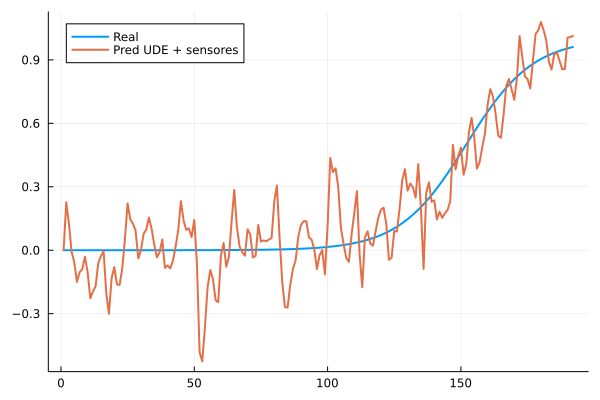

In [42]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

In [43]:
feature_cols = vcat(setting_cols, sensor_cols)

old_indices = [
    findfirst(==(s), names(train_df))
    for s in selected_sensors
]

new_indices = [
    findfirst(==(s), feature_cols)
    for s in selected_sensors
]

comparison = DataFrame(
    selected_sensor = selected_sensors,
    old_index_from_train_df = old_indices,
    old_actual_column_in_X = [
        idx <= length(feature_cols) ? feature_cols[idx] : missing
        for idx in old_indices
    ],
    new_index_in_X = new_indices,
    new_actual_column_in_X = feature_cols[new_indices]
)

comparison

Row,selected_sensor,old_index_from_train_df,old_actual_column_in_X,new_index_in_X,new_actual_column_in_X
,String,Int64,String?,Int64,String
1,s11,16,s13,14,s11
2,s15,20,s17,18,s15
3,s21,26,missing,24,s21
4,s20,25,missing,23,s20
5,s2,7,s4,5,s2


La curva predicha se ajusta bastante mejor a la real. Sin embargo, obtenemos un resultado ruidoso. (este es el comentario antes de agreagar indexacion...) empeoraron las cosas ni idea

## Regularización

Para dejar atrás los resultados ruidosos vamos a agregar términos de regularización a nuestra función de pérdida.

In [44]:
function loss_many_sensors_reg(p, trajs)

    total_loss = 0.0
    total_points = 0

    λ = 1e-10   # peso de regularización

    for traj in trajs

        pred = predict_traj_sensors(p, traj)
        y = traj.y

        # loss de ajuste
        data_loss = sum(abs2, pred .- y)

        # regularización de suavidad
        smoothness_loss = sum(abs2, diff(pred))

        total_loss += data_loss + λ * smoothness_loss

        total_points += length(y)

    end

    return total_loss / total_points

end

loss_many_sensors_reg (generic function with 1 method)

y repetimos lo de antes...

In [45]:
nn2 = Lux.Chain(
    Lux.Dense(input_dim, 8, tanh), 
    Lux.Dense(8, 1)
)

p_ude_sensors, st_ude_sensors = Lux.setup(rng, nn2)
p_ude_sensors = ComponentArray(p_ude_sensors)

ComponentVector{Float32}(layer_1 = (weight = Float32[-1.0375322 -0.041043606 … -0.1011211 -0.2172631; 0.6244983 0.11290994 … 0.5295402 0.56380624; … ; -0.05841965 0.5397521 … 0.33591306 1.0420023; 0.37671033 -0.8785523 … 0.61506915 -0.7013491], bias = Float32[0.008077797, -0.25260723, 0.022220204, -0.2935567, -0.21071051, -0.21734811, -0.22763613, -0.28947872]), layer_2 = (weight = Float32[-0.15927334 0.55633837 … 0.016644329 0.20036888], bias = Float32[0.06938488]))

In [46]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors_reg(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)


#agregamos early stopping...
best_loss = Inf
best_params = nothing

patience = 30
counter = 0
iter = 0
maxiters = 1000




result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=1000, #con 2000 ajusta mejor... actualizo: ahora me para el early stopping rapido nose que pasa
    callback=callback
)

p_trained_ude_sensors = best_params

#Los resultados son horribles. Lo que voy a probar despues es optimizar la f con termino de reg pero solo mirar el termino empirico para early stopping
#De esta manera puede ser que este mejorando la loss empirica pero todavia se siga ajustando la suavidad del resultado.

Iteración: 10 / 1000 | loss = 1111.1295180902916
Iteración: 20 / 1000 | loss = 1004.0754436624444
Iteración: 30 / 1000 | loss = 903.0540054822336
Iteración: 40 / 1000 | loss = 808.4765978360439
Iteración: 50 / 1000 | loss = 720.1363257054107
Iteración: 60 / 1000 | loss = 638.1243527984926
Iteración: 70 / 1000 | loss = 562.4980994540932
Iteración: 80 / 1000 | loss = 491.69971609009826
Iteración: 90 / 1000 | loss = 412.854614240477
Iteración: 100 / 1000 | loss = 229.13705868229496
Iteración: 110 / 1000 | loss = 163.45907617432087
Iteración: 120 / 1000 | loss = 152.74996266150268
Iteración: 130 / 1000 | loss = 146.11905409087632
Iteración: 140 / 1000 | loss = 134.79800277311614
Iteración: 150 / 1000 | loss = 142.61341920917377
Iteración: 160 / 1000 | loss = 138.12652848382353
Early stopping activado


ComponentVector{Float32}(layer_1 = (weight = Float32[-0.92706776 -0.13879186 … -0.22159775 -0.096645914; 0.5068882 0.21040031 … 0.64836264 0.43838972; … ; -0.15646707 0.6313135 … 0.4386137 0.9384521; 0.23503913 -0.75413907 … 0.7218475 -0.8091049], bias = Float32[-0.11356378, -0.13764326, 0.13001649, -0.17159167, -0.3326291, -0.33285987, -0.12926988, -0.18241641]), layer_2 = (weight = Float32[-0.06033473 0.4610392 … 0.11994615 0.10153631], bias = Float32[0.15689561]))

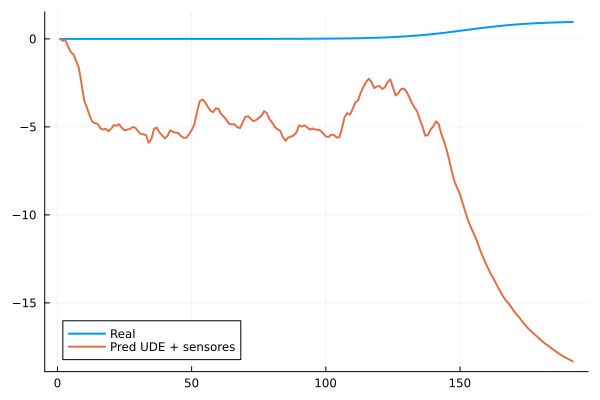

In [47]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

Si aumentamos las iteraciones se obtienen mejores resultados, pero igualmente no estamos planteando un escenario de entrenamiento y testeo óptimo.

## Entrenamiento y Testeo adecuado

Todo muy lindo con los resutados obtenidos al seleccionar los mejores sensores. Pero estamos entrenando con una sola trayectoria y evaluando en la misma trayectoria que entrenamos. Por lo tanto, vamos a realizar lo siguiente:

+ Entrenar con x (todavía nose) trayectorias.

+ Testear con trayectorias fuera de nuestro set de entrenamiento

Antes de seguir vamos a definir una funcion para que nos devuelva set de entrenamiento y testo:

In [48]:
function build_train_test_trajs_sensors(trajectories;n_motors=nothing,test_ratio=0.2,shuffle=false,sensors=nothing,seed=67)

    total_motors = length(trajectories)

    selected_ids = collect(1:total_motors)

    # shuffle opcional (solo para definir el orden base)
    if shuffle
        rng = MersenneTwister(seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    # elegir subset de motores
    if n_motors !== nothing
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = selected_ids[1:n]
    end

    # split train/test (20% test, siguientes en la lista)
    n_test = Int(round(test_ratio * length(selected_ids)))
    test_ids = selected_ids[end - n_test + 1:end]
    train_ids = selected_ids[1:end - n_test]

    # default sensors
    if sensors === nothing
        sensors = 4:size(trajectories[1].X, 2)
    end

    # helper para construir dataset
    function build(ids)
        trajs = []

        for i in ids

            t = Float64.(trajectories[i].t)
            S = Float64.(trajectories[i].X[:, sensors])

            sensor_interps = [
                LinearInterpolation(S[:, j], t)
                for j in 1:size(S,2)
            ]

            push!(trajs,
                (
                    sensor_interps = sensor_interps,
                    sensors_ids = sensors,
                    t = t,
                    y = Float64.(trajectories[i].y)
                )
            )
        end

        return trajs
    end

    train_trajs = build(train_ids)
    test_trajs  = build(test_ids)

    return train_trajs, test_trajs
end

build_train_test_trajs_sensors (generic function with 1 method)

In [49]:
#Definimos trayectorias de entrenamiento:
train_trajs, test_trajs = build_train_test_trajs_sensors(
    trajectories;
    n_motors=10,
    test_ratio = 0.2,
    sensors = sensor_indices
)


n_sensors = length(train_trajs[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

usando 10 de 100 motores
Cantidad de sensores usados: 5


(Chain{@NamedTuple{layer_1::Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}((layer_1 = Dense(7 => 8, tanh), layer_2 = Dense(8 => 1)), nothing), (layer_1 = (weight = Float32[-0.7408691 -0.10326696 … -0.31419405 0.60451025; -1.0432168 0.3961915 … -0.37899157 0.34615695; … ; 0.71916956 -0.96607554 … 0.13166444 -0.49240565; 0.6046512 -0.64713013 … -0.20698707 0.8680423], bias = Float32[0.22285166, -0.17147908, 0.34149525, 0.09755093, -0.2741171, -0.075842164, -0.33706185, 0.16103292]), layer_2 = (weight = Float32[0.32925278 0.0061875214 … 0.4209173 -0.17584868], bias = Float32[0.12733962])), (layer_1 = NamedTuple(), layer_2 = NamedTuple()))

In [50]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)

#tengo que inicializar nuevamente los parametros del early-stopping

best_loss = Inf
best_params = nothing
patience = 30
counter = 0
iter = 0
maxiters = 500


display("Iniciando optimización...")


result_ude_sensors = @time Optimization.solve( #agrego @time para ver cuanto tarda
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=500, 
    callback=callback
)

p_trained_ude_sensors = best_params
#lo dejo anotado aca, esto tardo 17 minutos con 10 motores y 5 sensores, con early stopping.

"Iniciando optimización..."

Iteración: 10 / 500 | loss = 0.5255154107527242
Iteración: 20 / 500 | loss = 0.2931782453331925
Iteración: 30 / 500 | loss = 0.21085848902461915
Iteración: 40 / 500 | loss = 0.17633647228735688
Iteración: 50 / 500 | loss = 0.16002313378208827
Iteración: 60 / 500 | loss = 0.15106556694354945
Iteración: 70 / 500 | loss = 0.14513511319295536
Iteración: 80 / 500 | loss = 0.14049309780071514
Iteración: 90 / 500 | loss = 0.1364573813988328
Iteración: 100 / 500 | loss = 0.1327679107905561
Iteración: 110 / 500 | loss = 0.12932622779280176
Iteración: 120 / 500 | loss = 0.12608158084838364
Iteración: 130 / 500 | loss = 0.12301310619898706
Iteración: 140 / 500 | loss = 0.12009690202397305
Iteración: 150 / 500 | loss = 0.11732018859546588
Iteración: 160 / 500 | loss = 0.11467059163656387
Iteración: 170 / 500 | loss = 0.11214029035436737
Iteración: 180 / 500 | loss = 0.10971587721845331
Iteración: 190 / 500 | loss = 0.10739673634252846
Iteración: 200 / 500 | loss = 0.10517449360428689
Iteración: 21

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.83530235 -0.040171318 … -0.26282963 0.5861521; -1.3351097 0.5231374 … -0.2544361 0.3525367; … ; 0.66331905 -0.9188188 … 0.1854712 -0.52467185; 0.69943434 -0.6991741 … -0.25687823 0.8552372], bias = Float32[0.24963664, -0.14982587, 0.34914416, 0.102483496, -0.28751823, -0.10396973, -0.3077372, 0.1412248]), layer_2 = (weight = Float32[0.38288772 0.05707184 … 0.31861874 -0.23897165], bias = Float32[0.15071826]))

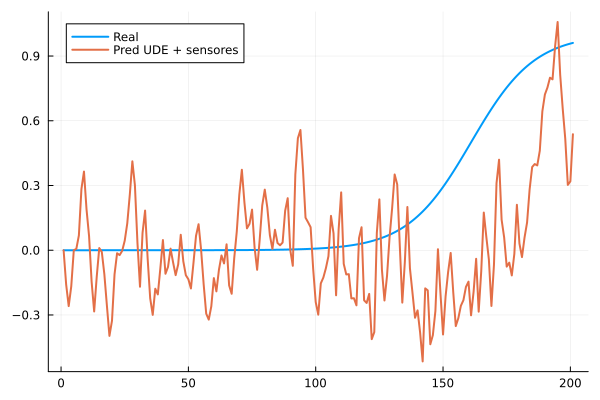

In [51]:
traj_plot = test_trajs[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)


p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

## Cosas para mejorar:

+ Ver la forma de entrenar no con la trayectoria completa sino ir viendo partes de las trayectorias. Asi podemos usar mas trayectorias para entrenar y hacerlo en un tiempo razonable

+ Evaluar otro modelo. Ahora no agregamos reestricciones sobre que tiene que estar entre 0 y 1.

# TOMAR LO SIG CON PINZAS

## Evaluo modelo sigmoide, encierro la proba entre 0 y 1

Modelamos una variable latente \(z(t)\), y no directamente la probabilidad de falla. La predicción final se obtiene aplicando una sigmoide:

$$
\widehat{p}_{fail}(t)
=
\sigma(z(t))
=
\frac{1}{1+e^{-z(t)}}.
$$
La UDE con sensores queda dada por:

$$
\frac{dz}{dt}
=
-\alpha z(t)
+
NN_{\theta}
\left(
\sigma(z(t)),
\tau(t),
S(t)
\right),
$$

donde

$$
\tau(t)
=
\frac{t-t_0}{t_f-t_0}
$$

y

$$
S(t)
=
(s_1(t),\dots,s_k(t))
$$

corresponde a los sensores interpolados en el tiempo \(t\).

In [78]:
function logit(p; ϵ=1e-6)
    p_clamped = clamp(p, ϵ, 1 - ϵ)
    return log(p_clamped / (1 - p_clamped))
end


logit (generic function with 1 method)

$$
z(t_0)
=
\operatorname{logit}(p_{fail}(t_0))
=
\log\left(
\frac{p_{fail}(t_0)}
{1-p_{fail}(t_0)}
\right).
$$

In [79]:
function ude_sensors_latent!(du, z, p, τ, S)

    p_hat = σ(z[1])

    input = (vcat([p_hat, τ], S)) #pasar a float32 rompe, idk why
    #input = Float32.(vcat([p_hat, τ], S))
    out, _ = nn2(input, p, st_ude_sensors)

    du[1] = -α * z[1] + out[1]

end


ude_sensors_latent! (generic function with 1 method)

In [80]:
function predict_traj_sensors_positive(p, traj)

    tvec = traj.t
    y = traj.y

    z0 = [logit(y[1])]

    t0 = tvec[1]
    tf = tvec[end]
    tspan = (t0, tf)

    function f!(du, z, p, t)

        S = [
            interp(clamp(t, t0, tf))
            for interp in traj.sensor_interps
        ]

        τ = (t - t0) / (tf - t0)

        ude_sensors_latent!(du, z, p, τ, S)

    end

    prob = ODEProblem(f!, z0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax=1.0
    )

    z_pred = Array(sol)[1, :]

    p_pred = σ.(z_pred)

    return p_pred

end

predict_traj_sensors_positive (generic function with 1 method)

In [81]:
function loss_many_sensors_positive(p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj_sensors_positive(p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points

end

loss_many_sensors_positive (generic function with 1 method)

La pérdida se calcula sobre la probabilidad transformada:

$$
\mathcal{L}(\theta)
=
\frac{1}{\sum_{i=1}^{M}T_i}
\sum_{i=1}^{M}
\sum_{j=1}^{T_i}
\left(
\sigma(z_i(t_{i,j};\theta))
-
p_{fail,i,j}
\right)^2.
$$

In [82]:
nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors_positive(x, train_trajs),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)
best_loss = Inf
best_params = nothing
patience = 30
counter = 0
iter = 0
maxiters = 1000


result_ude_sensors = @time Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=1000,
    callback=callback
)

p_trained_ude_sensors = best_params
#lo dejo anotado aca, esto tardo 2 minutos con 10 motores y 5 sensores, con early stopping. 

Iteración: 10 / 1000 | loss = 0.024522929815277008
Iteración: 20 / 1000 | loss = 0.02252394764519599
Iteración: 30 / 1000 | loss = 0.020782516040975366
Iteración: 40 / 1000 | loss = 0.019280849017905822
Iteración: 50 / 1000 | loss = 0.01796581918975566
Iteración: 60 / 1000 | loss = 0.016807523157537717
Iteración: 70 / 1000 | loss = 0.01577686133271544
Iteración: 80 / 1000 | loss = 0.014848929355374517
Iteración: 90 / 1000 | loss = 0.014006759317986797
Iteración: 100 / 1000 | loss = 0.013234234686399757
Iteración: 110 / 1000 | loss = 0.012520265615038032
Iteración: 120 / 1000 | loss = 0.01185607628565578
Iteración: 130 / 1000 | loss = 0.011235336711404049
Iteración: 140 / 1000 | loss = 0.010649991251483994
Iteración: 150 / 1000 | loss = 0.01009584775439299
Iteración: 160 / 1000 | loss = 0.00956877208208101
Iteración: 170 / 1000 | loss = 0.009065975420883155
Iteración: 180 / 1000 | loss = 0.008585274449979596
Iteración: 190 / 1000 | loss = 0.00812243646183759
Iteración: 200 / 1000 | loss

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.8388073 0.079587154 … -0.30746517 0.8127122; -1.2146285 0.6116826 … -0.021902546 0.46871996; … ; 0.7959503 -0.589446 … 0.15614074 -0.6133337; 0.64727926 -0.80657023 … 0.37260288 0.92095715], bias = Float32[0.4625724, -0.9036013, 0.4586475, -0.061283346, -0.7473976, -0.14856622, -0.1792496, 0.34523404]), layer_2 = (weight = Float32[-0.123146616 0.00952475 … 0.21808381 -0.2932297], bias = Float32[-0.240353]))

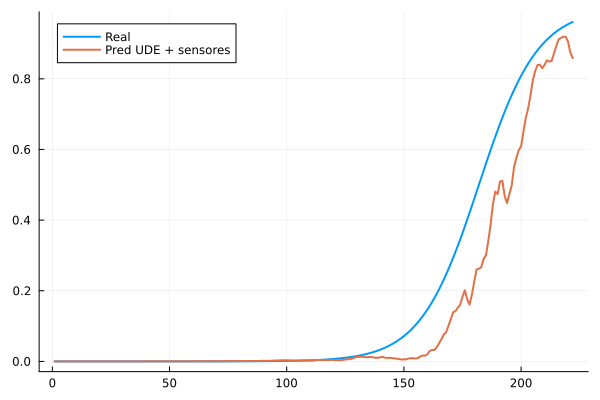

In [83]:
traj_plot = test_trajs[2]


pred_ude_sensors = predict_traj_sensors_positive(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)


# TOMAR LO anterior CON PINZAS

# Veamos si podemos agarrar ventanas de motores

## Generemos n ventanas uniformemente a lo largo de la trayectoria i, de m tamaño

In [84]:
function _even_indices(N, n) #even indices es para tomar n indices uniformemente espaciados entre 1 y N

    if n <= 0
        return Int[]
    end

    n_eff = min(n, N)

    return unique(round.(Int, range(1, stop=N, length=n_eff)))

end


function _make_window(trajs, traj_idx, start_idx, end_idx, kind) #kind es para saber si la ventana es unif o late

    traj = trajs[traj_idx]

    return (
        t = traj.t[start_idx:end_idx],
        y = traj.y[start_idx:end_idx],
        sensor_interps = traj.sensor_interps,

        #tiempos de la trayectoria completa
        #necesarios para normalizar τ y evaluar interpoladores
        full_t0 = traj.t[1],
        full_tf = traj.t[end],

        #metadata útil para debug
        traj_idx = traj_idx,
        start_idx = start_idx,
        end_idx = end_idx,
        kind = kind
    )

end


function window_prep(trajs; n_uniform=30, n_late=20, m=40, shuffle=true, seed=1234)

    rng = MersenneTwister(seed)

    # Nos quedamos solo con trayectorias que soporten ventanas de tamaño m
    valid_traj_idxs = [
        i for i in eachindex(trajs)
        if length(trajs[i].t) >= m
    ]

    if length(valid_traj_idxs) == 0
        error("No hay trayectorias con longitud >= m.")
    end

    # ============================================================
    # 1. Ventanas uniformes
    # ============================================================

    uniform_candidates = []

    for traj_idx in valid_traj_idxs

        T = length(trajs[traj_idx].t)

        for start_idx in 1:(T - m + 1)

            end_idx = start_idx + m - 1

            push!(
                uniform_candidates,
                (traj_idx = traj_idx, start_idx = start_idx, end_idx = end_idx)
            )

        end
    end

    uniform_idxs = _even_indices(length(uniform_candidates), n_uniform)

    uniform_windows = [
        _make_window(
            trajs,
            uniform_candidates[idx].traj_idx,
            uniform_candidates[idx].start_idx,
            uniform_candidates[idx].end_idx,
            :uniform
        )
        for idx in uniform_idxs
    ]

    # ============================================================
    # 2. Ventanas tardías
    # ============================================================

    #el metodo que uso es calcular la derivada en cada punto de la ventana y tomar promedio. Luego nos quedamos con la ventana que maximice ese promedio.
    #a mayor derivada mayor cambio, entonces nos estariamos quedando con la ventana que da mas cambio.
    
    late_candidates = []

    for traj_idx in valid_traj_idxs

        y = trajs[traj_idx].y
        T = length(y)

        dy = abs.(diff(y))

        best_score = -Inf
        best_start = 1

        # recorremos todas las ventanas posibles
        for start_idx in 1:(T - m + 1)

            end_idx = start_idx + m - 1

            # derivadas dentro de la ventana
            local_dy = dy[start_idx:(end_idx - 1)]

            # score = derivada promedio
            score = mean(local_dy)

            if score > best_score

                best_score = score
                best_start = start_idx

            end
        end

        push!(
            late_candidates,
            (
                traj_idx = traj_idx,
                start_idx = best_start,
                end_idx = best_start + m - 1
            )
        )

    end

    late_idxs = _even_indices(length(late_candidates), n_late)

    late_windows = [
        _make_window(
            trajs,
            late_candidates[idx].traj_idx,
            late_candidates[idx].start_idx,
            late_candidates[idx].end_idx,
            :late
        )
        for idx in late_idxs
    ]

    # ============================================================
    # 3. Unimos ambas clases de ventanas
    # ============================================================

    windows = vcat(uniform_windows, late_windows)

    if shuffle
        windows = windows[randperm(rng, length(windows))]
    end



    # ============================================================
    # 4. Resumen de ahorro por trayectoria
    # ============================================================

    savings_rows = []

    for traj_idx in eachindex(trajs)

        full_points = length(trajs[traj_idx].t)

        traj_windows = [
            w for w in windows
            if w.traj_idx == traj_idx
        ]

        n_windows_traj = length(traj_windows)

        n_uniform_traj = count(w -> w.kind == :uniform, traj_windows)
        n_late_traj = count(w -> w.kind == :late, traj_windows)

        window_points = sum(length(w.t) for w in traj_windows)

        saved_points = full_points - window_points

        saving_pct = 100 * saved_points / full_points

        push!(
            savings_rows,
            (
                traj_idx = traj_idx,
                full_points = full_points,
                n_windows = n_windows_traj,
                n_uniform = n_uniform_traj,
                n_late = n_late_traj,
                window_points = window_points,
                saved_points = saved_points,
                saving_pct = saving_pct
            )
        )

    end

    savings_df = DataFrame(savings_rows)

    total_full_points = sum(savings_df.full_points)
    total_window_points = sum(savings_df.window_points)
    total_saved_points = total_full_points - total_window_points
    total_saving_pct = 100 * total_saved_points / total_full_points

    #display("algo",var) no funciona, hay q usar d

    display("Ventanas uniformes generadas: "); display(length(uniform_windows))
    display("Ventanas tardías generadas: "); display(length(late_windows))
    display("Ventanas totales: "); display(length(windows))
    display("Tamaño de cada ventana: "); display(m)
    display("")
    display("Puntos usando trayectorias completas: "); display(total_full_points)
    display("Puntos usando ventanas: "); display(total_window_points)
    display("Puntos ahorrados: "); display(total_saved_points)
    display("Ahorro porcentual total: "); display(round(total_saving_pct, digits=2)); display("%")

    return windows, savings_df

end


window_prep (generic function with 1 method)

In [85]:
function predict_window_sensors_positive(p, window)

    tvec = window.t
    y = window.y

    z0 = [logit(y[1])]

    # Intervalo de la ventana
    t0_window = tvec[1]
    tf_window = tvec[end]
    tspan = (t0_window, tf_window)

    # Intervalo de la trayectoria completa
    full_t0 = window.full_t0
    full_tf = window.full_tf

    function f!(du, z, p, t)

        S = [
            interp(clamp(t, full_t0, full_tf))
            for interp in window.sensor_interps
        ]

        τ = (t - full_t0) / (full_tf - full_t0)

        ude_sensors_latent!(du, z, p, τ, S)

    end

    prob = ODEProblem(f!, z0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax=1.0
    )

    z_pred = Array(sol)[1, :]

    p_pred = σ.(z_pred)

    return p_pred

end

predict_window_sensors_positive (generic function with 1 method)

In [86]:
function loss_many_windows_positive(p, windows)

    total_loss = 0.0
    total_points = 0

    for window in windows

        pred = predict_window_sensors_positive(p, window)
        y = window.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)

    end

    return total_loss / total_points

end

loss_many_windows_positive (generic function with 1 method)

In [87]:
train_w, savings_df = window_prep(
    train_trajs;
    n_uniform=20,
    n_late=10,
    m=40,
    shuffle=true,
    seed=1234
)

train_windows = train_w
savings_df = savings_df

"Ventanas uniformes generadas: "

20

"Ventanas tardías generadas: "

8

"Ventanas totales: "

...

593

"Ahorro porcentual total: "

34.62

"%"

Row,traj_idx,full_points,n_windows,n_uniform,n_late,window_points,saved_points,saving_pct
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64
1,1,192,4,3,1,160,32,16.6667
2,2,287,4,3,1,160,127,44.2509
3,3,179,3,2,1,120,59,32.9609
4,4,189,3,2,1,120,69,36.5079
5,5,269,4,3,1,160,109,40.5204
6,6,188,3,2,1,120,68,36.1702
7,7,259,4,3,1,160,99,38.2239
8,8,150,3,2,1,120,30,20.0


In [88]:
function predict_window_sensors_positive(p, window)

    tvec = window.t
    y = window.y

    z0 = [logit(y[1])]

    # intervalo corto de la ventana
    t0_window = tvec[1]
    tf_window = tvec[end]
    tspan = (t0_window, tf_window)

    # intervalo de la trayectoria completa
    full_t0 = window.full_t0
    full_tf = window.full_tf

    function f!(du, z, p, t)

        S = [
            interp(clamp(t, full_t0, full_tf))
            for interp in window.sensor_interps
        ]

        τ = (t - full_t0) / (full_tf - full_t0)

        ude_sensors_latent!(du, z, p, τ, S)

    end

    prob = ODEProblem(f!, z0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax=1.0
    )

    z_pred = Array(sol)[1, :]

    return σ.(z_pred)

end

predict_window_sensors_positive (generic function with 1 method)

In [89]:
nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

optf_ude_windows = OptimizationFunction(
    (x, _) -> loss_many_windows_positive(x, train_windows),
    AutoZygote()
)

optprob_ude_windows = OptimizationProblem(
    optf_ude_windows,
    p_ude_sensors
)

best_loss = Inf
best_params = nothing
patience = 30
counter = 0
iter = 0
maxiters = 500

result_ude_windows = @time Optimization.solve(
    optprob_ude_windows,
    Adam(1e-3),
    maxiters=maxiters,
    callback=callback
)

p_trained_ude_windows = best_params
#tardo 5 min, 10 motores, sensores ver arriba, ventanas de 40 puntos, con early stopping

Iteración: 10 / 500 | loss = 0.0327970339695165
Iteración: 20 / 500 | loss = 0.03022719891337977
Iteración: 30 / 500 | loss = 0.02862692203774229
Iteración: 40 / 500 | loss = 0.0270324803326723
Iteración: 50 / 500 | loss = 0.025415532696401427
Iteración: 60 / 500 | loss = 0.023809117596947274
Iteración: 70 / 500 | loss = 0.02217489885709358
Iteración: 80 / 500 | loss = 0.020512990312874915
Iteración: 90 / 500 | loss = 0.01882004970292577
Iteración: 100 / 500 | loss = 0.017108400616279544
Iteración: 110 / 500 | loss = 0.015404165698042739
Iteración: 120 / 500 | loss = 0.013714159922697318
Iteración: 130 / 500 | loss = 0.012052801048149904
Iteración: 140 / 500 | loss = 0.010424897105360102
Iteración: 150 / 500 | loss = 0.008835706136339152
Iteración: 160 / 500 | loss = 0.00730815718062969
Iteración: 170 / 500 | loss = 0.005893085540658874
Iteración: 180 / 500 | loss = 0.00466821294505781
Iteración: 190 / 500 | loss = 0.0036969328529872733
Iteración: 200 / 500 | loss = 0.00298094880648555

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.80704445 0.0038966958 … -0.23541628 0.71528894; -1.1351966 0.35374725 … -0.2832693 0.22698162; … ; 0.8922694 -0.65326434 … 0.02909546 -0.43575224; 0.6261978 -0.8400208 … -0.19492306 0.72140634], bias = Float32[0.2045651, 0.20694798, 0.47142696, 0.18574852, -0.46844727, -0.19112432, -0.1551384, 0.18061647]), layer_2 = (weight = Float32[0.1405383 -0.23163038 … 0.28692168 -0.22314392], bias = Float32[0.031059556]))

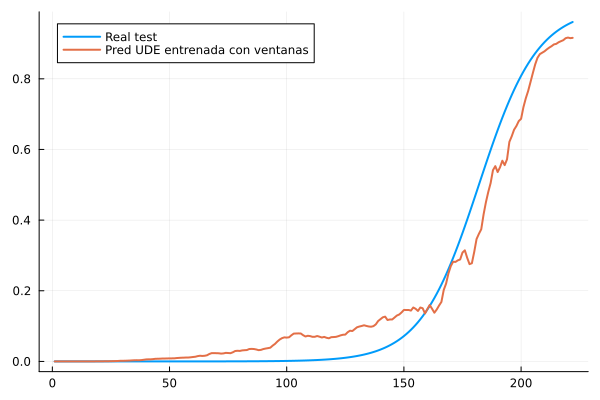

In [90]:
traj_plot = test_trajs[2]

pred_test = predict_traj_sensors_positive(
    p_trained_ude_windows,
    traj_plot
)

p = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real test",
    linewidth=2
)

plot!(
    p,
    traj_plot.t,
    pred_test,
    label="Pred UDE entrenada con ventanas",
    linewidth=2
)

p